In [1]:
import my_functions
from my_functions import *
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
my_games = import_games("rajakel_all_games.pgn")

In [3]:
my_games

{1: {'Event': "Let's Play!",
  'Site': 'Chess.com',
  'Date': '2021.11.30',
  'Round': '-',
  'White': 'rajakel',
  'Black': 'Lracking',
  'Result': '0-1',
  'CurrentPosition': 'r4r1k/pQp1B2p/2n1b3/b3p3/4p2p/2P5/P2PKp1P/RN2q3 w - - 0 22',
  'Timezone': 'UTC',
  'ECO': 'A00',
  'ECOUrl': 'https://www.chess.com/openings/Polish-Opening-1...e5',
  'UTCDate': '2021.11.30',
  'UTCTime': '07:47:56',
  'WhiteElo': '800',
  'BlackElo': '755',
  'TimeControl': '1/86400',
  'Termination': 'Lracking won by checkmate',
  'StartTime': '07:47:56',
  'EndDate': '2021.11.30',
  'EndTime': '22:00:54',
  'Link': 'https://www.chess.com/game/daily/370293923',
  'game_pgn': '1. b4 {[%clk 0:00:01.6]} 1... e5 {[%clk 0:00:07.3]} 2. e4 {[%clk 0:00:01.5]} 2... Bxb4 {[%clk 0:00:00.7]} 3. c3 {[%clk 0:00:01.5]} 3... Ba5 {[%clk 0:00:01.8]} 4. Nf3 {[%clk 0:00:06.1]} 4... Nc6 {[%clk 0:00:01.8]} 5. Be2 {[%clk 0:00:02.7]} 5... f6 {[%clk 0:00:02.7]} 6. Nh4 {[%clk 0:00:04.7]} 6... Nge7 {[%clk 0:00:08.6]} 7. O-O {[%clk 0:0

In [4]:
my_openings = {}

for id, game in my_games.items():
    temp_opening = game["ECO"]
    if temp_opening in my_openings:
        my_openings[temp_opening]["count"] += 1
    else:
        my_openings[temp_opening]  = {"name": game["ECOUrl"].split(r"/")[-1].replace("-", " ") , "count" : 0, "link" : game["ECOUrl"]}
    my_games[id]["Opening"] = my_openings[temp_opening]["name"]
my_openings = dict(sorted(my_openings.items(), key = lambda x : x[1]["count"], reverse = True))
my_openings

{'B01': {'name': 'Scandinavian Defense 2.exd5 e5 3.dxe6',
  'count': 1625,
  'link': 'https://www.chess.com/openings/Scandinavian-Defense-2.exd5-e5-3.dxe6'},
 'C20': {'name': 'Kings Pawn Opening Leonardis Variation',
  'count': 735,
  'link': 'https://www.chess.com/openings/Kings-Pawn-Opening-Leonardis-Variation'},
 'C00': {'name': 'French Defense Knight Variation',
  'count': 597,
  'link': 'https://www.chess.com/openings/French-Defense-Knight-Variation'},
 'B00': {'name': 'Kings Pawn Opening',
  'count': 467,
  'link': 'https://www.chess.com/openings/Kings-Pawn-Opening'},
 'B07': {'name': 'Pirc Defense Lions Jaw Variation 3...d5 4.e5 Nfd7 5.f4',
  'count': 397,
  'link': 'https://www.chess.com/openings/Pirc-Defense-Lions-Jaw-Variation-3...d5-4.e5-Nfd7-5.f4'},
 'A00': {'name': 'Polish Opening 1...e5',
  'count': 377,
  'link': 'https://www.chess.com/openings/Polish-Opening-1...e5'},
 'D00': {'name': 'Queens Pawn Opening 1...d5 2.e3',
  'count': 349,
  'link': 'https://www.chess.com/op

In [20]:
my_games_df = pd.DataFrame(data=my_games)
my_games_df = my_games_df.T
my_games_df.index = (pd.to_datetime(my_games_df.index))
my_games_df = my_games_df[my_games_df["Variant"].isna()]
my_games_df = my_games_df.set_index("EndDate")
my_games_df = my_games_df.loc[my_games_df.index > "2024-12-31", :]
my_games_df = my_games_df.loc[my_games_df.index < "2026-07-01", :]
my_games_df["isWhite"] = my_games_df["White"] == "rajakel"
my_games_df["isBlack"] = my_games_df["Black"] == "rajakel"
my_games_df = add_opening_group(my_games_df)
my_games_df.drop(["SetUp", "FEN", "Variant"], axis=1)
my_games_df.head(2)

,Event,Site,Date,Round,White,Black,Result,CurrentPosition,Timezone,ECO,...,EndTime,Link,game_pgn,Opening,Variant,SetUp,FEN,isWhite,isBlack,Opening_Group
EndDate,,,,,,,,,,,,,,,,,,,,,
2024.11.06,Live Chess,Chess.com,2024.11.06,-,rajakel,nadiyabdelkarim,0-1,2r1k3/6p1/3K4/8/8/7p/8/8 w - -,UTC,D00,...,21:04:14,https://www.chess.com/game/live/124665591979,1. d4 {[%clk 0:03:00]} 1... d5 {[%clk 0:03:00]...,Queens Pawn Opening 1...d5 2.e3,NaN,NaN,NaN,True,False,Queen's Pawn Opening
2024.11.06,Live Chess,Chess.com,2024.11.06,-,rajakel,nadiyabdelkarim,0-1,2r1k3/6p1/3K4/8/8/7p/8/8 w - -,UTC,D00,...,21:04:14,https://www.chess.com/game/live/124665591979,1. d4 {[%clk 0:03:00]} 1... d5 {[%clk 0:03:00]...,Queens Pawn Opening 1...d5 2.e3,NaN,NaN,NaN,True,False,Queen's Pawn Opening


In [19]:
my_games_df.to_csv(path_or_buf= "./mygames.csv", mode= "w")

## Cleaning data for openings analysis

In [7]:
historical_openings_df = my_games_df[["EndDate", "Opening", "isWhite", "isBlack"]].set_index("EndDate")
historical_openings_df

,Opening,isWhite,isBlack
EndDate,,,
2025-01-05,Indian Game Knights Variation 2...e6 3.Nc3,True,False
2025-01-05,Indian Game Knights Variation 2...e6 3.Nc3,True,False
2025-02-26,Queens Pawn Opening Zukertort Variation 2...e6...,True,False
2025-02-24,Queens Pawn Opening 1...d5 2.e3,True,False
2025-02-21,Kings Pawn Opening,False,True
...,...,...,...
2026-06-01,Pirc Defense Lions Jaw Variation 3...d5 4.e5 N...,False,True
2026-06-01,Kings Pawn Opening,False,True
2026-06-01,Scandinavian Defense 2.exd5 e5 3.dxe6,True,False


In [8]:
historical_openings_df = add_opening_group(historical_openings_df)

In [9]:
monthly = (
    historical_openings_df.groupby(pd.Grouper(freq="ME"))["Opening_Group"]
      .value_counts()
      .unstack(fill_value=0)
)

In [10]:
monthly.sum()

Opening_Group
Alekhine Defense              100
Benoni Defense                 10
Bird Opening                   24
Bishop's Opening              330
Caro-Kann Defense             182
Center Game                    26
Colle System                   38
English Opening                30
Englund Gambit                254
Four Knights Game              78
French Defense                668
Grunfeld Defense                4
Indian Game                   112
Italian Game                  164
King's Gambit                 280
King's Indian                  44
King's Pawn Opening          1216
Modern Defense                156
Nimzowitsch-Larsen Attack      38
Old Indian Defense             12
Petrov Defense                  8
Philidor Defense               18
Pirc Defense                  434
Polish Opening                370
Ponziani Opening               70
Queen's Gambit                 44
Queen's Pawn Opening          544
Reti Opening                  114
Ruy Lopez                       6


In [11]:
monthly = monthly.loc[monthly.index > "2024-12-31" , monthly.sum() >= 200]
monthly = monthly.loc[monthly.index < "2026-07-01"]
monthly

Opening_Group,Bishop's Opening,Englund Gambit,French Defense,King's Gambit,King's Pawn Opening,Pirc Defense,Polish Opening,Queen's Pawn Opening,Scandinavian Defense,Vienna Game
EndDate,,,,,,,,,,
2025-01-31,0,0,0,0,0,0,0,0,0,0
2025-02-28,0,2,0,0,2,2,2,8,0,0
2025-03-31,8,20,4,0,10,2,16,44,2,6
2025-04-30,8,30,18,2,50,76,24,66,16,2
2025-05-31,2,66,140,0,220,22,26,16,48,0
2025-06-30,2,52,104,0,154,14,28,0,46,2
2025-07-31,2,44,118,0,166,14,16,10,36,0
2025-08-31,2,18,132,0,168,20,40,14,60,2
2025-09-30,40,4,26,0,104,8,18,60,162,16


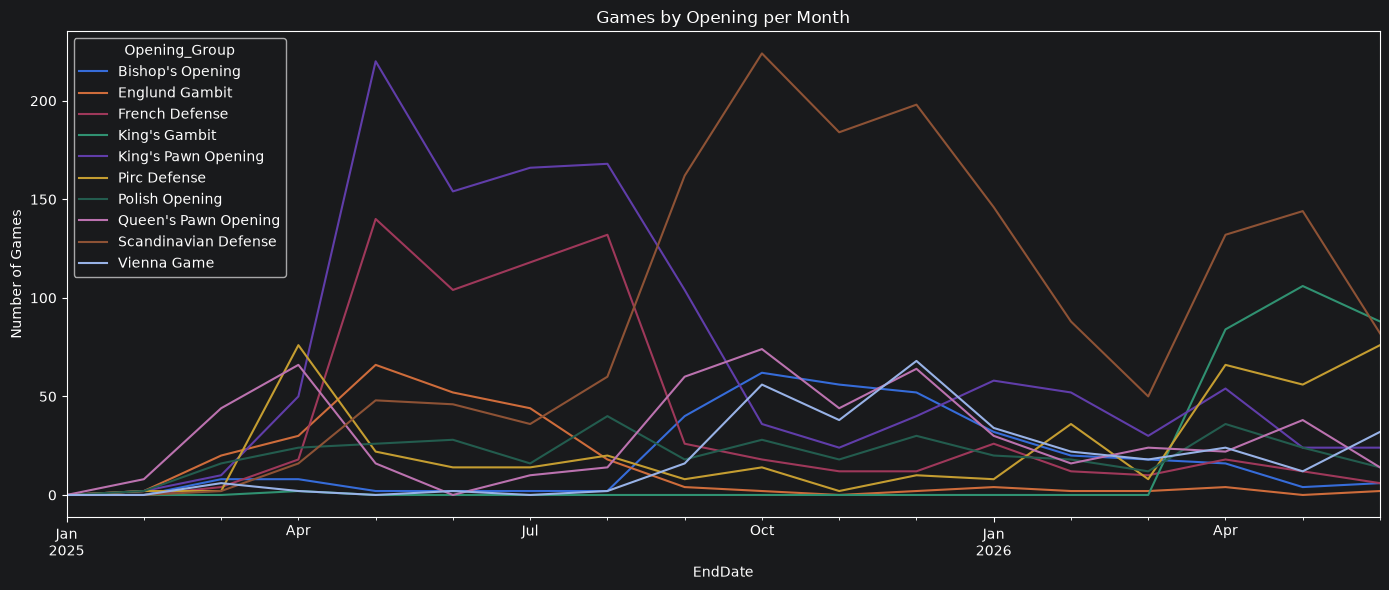

In [12]:
monthly.plot(figsize=(14, 6))
plt.title("Games by Opening per Month")
plt.ylabel("Number of Games")
plt.tight_layout()
plt.show()

## Monthly openings used, segmented by color played

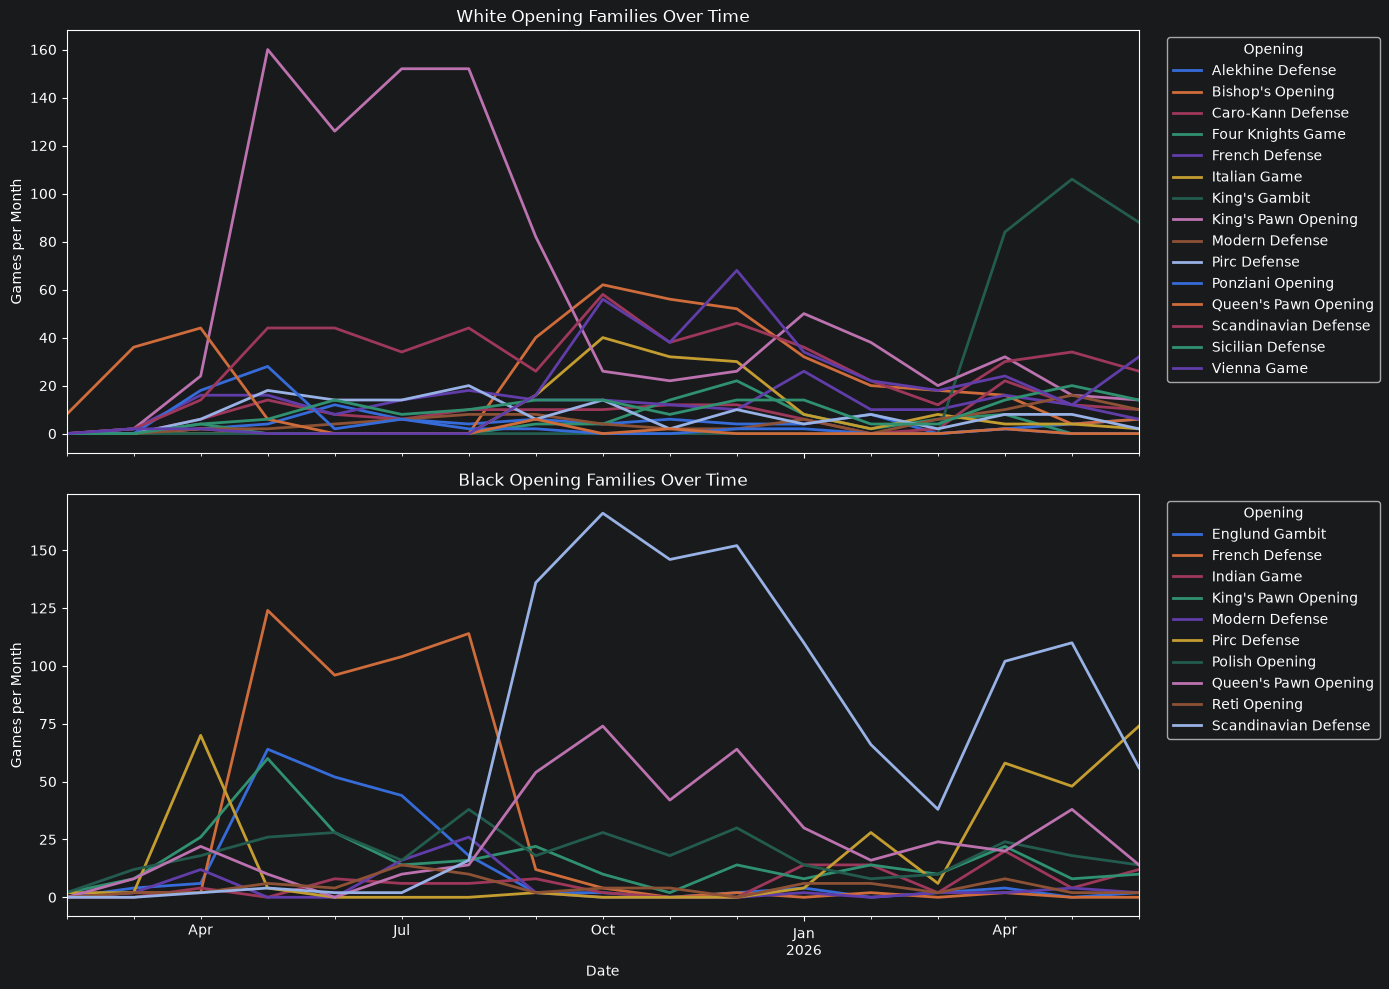

In [13]:
monthly_opening_counts_by_color(historical_openings_df)